## Simulation of hits from windows chosen by probability

In [2]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 
import math

from helpers import geometry, rwbeams, sampler, rwhist, collision, coord

# Geometry

In [3]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.001 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

### Import of the excel data frame

In [4]:
# =====================================================
# Chargement de la configuration Master
# =====================================================

# On utilise le module beams pour lire et VALIDER le fichier excel
# que tu as créé dans ton notebook "parameters"
df_omega = rwbeams.read_beams("omega60_master_config.xlsx")


df_omega.head()

,id,LAT_rad,LONG_rad,energy,wavelength,l1,l2,xc,yc,zc,...,t1x,t1y,t1z,t2x,t2y,t2z,R,fx,fy,fz
0,OMEGA_J01,0.203169,1.570796,500,3.510000e-07,0.28,0.28,2.038592e-17,0.332927,1.616063,...,-1.000000,6.123234e-17,0,-5.997292e-17,-0.979432,0.201774,0.14,-2.059183e-19,-0.003363,-0.016324
1,OMEGA_J02,0.203169,4.712389,500,3.510000e-07,0.28,0.28,-6.115775e-17,-0.332927,1.616063,...,1.000000,-1.836970e-16,0,1.799188e-16,0.979432,0.201774,0.14,6.177550e-19,0.003363,-0.016324
2,OMEGA_J03,0.545768,0.890581,500,3.510000e-07,0.28,0.28,5.386876e-01,0.665855,1.410303,...,-0.777438,6.289602e-01,0,-5.375904e-01,-0.664498,0.519075,0.14,-5.441289e-03,-0.006726,-0.014245
3,OMEGA_J04,0.545768,2.251011,500,3.510000e-07,0.28,0.28,-5.386876e-01,0.665855,1.410303,...,-0.777438,-6.289602e-01,0,5.375904e-01,-0.664498,0.519075,0.14,5.441289e-03,-0.006726,-0.014245
4,OMEGA_J05,0.545768,4.032174,500,3.510000e-07,0.28,0.28,-5.386876e-01,-0.665855,1.410303,...,0.777438,-6.289602e-01,0,5.375904e-01,0.664498,0.519075,0.14,5.441289e-03,0.006726,-0.014245


## INPUT

In [5]:
# --- Execution ---

N_total=60000 #Number of impact (rays) that you want to simulate


total_impact = collision.impact_simulated(N_total, TARGET_RADIUS, np.array([0.0, 0.0, 0.0]), df_omega)

print(f"Simulation Monte-Carlo complétée.")
print(f"Total de rayons lancés : {N_total}")
print(f"Total d'impacts enregistrés sur la cible : {len(total_impact)}")

total_impact.head()

Simulation terminée : 59999 impacts valides enregistrés.
Simulation Monte-Carlo complétée.
Total de rayons lancés : 60000
Total d'impacts enregistrés sur la cible : 59999


,id,cs,l,xx,xy,xz,ux,uy,uz,xsphx,xsphy,xsphz,nx,ny,nz,r,long_rad,lat_rad,R,energy_weight
0,OMEGA_J01,-0.9499,1.6493,-0.0288,0.3448,1.6136,0.0173,-0.2088,-0.9778,-0.0003,0.0003,0.0009,-0.3044,0.3157,0.8987,0.001,2.3381,0.4540,0.14,0.4995
1,OMEGA_J01,-0.9693,1.6492,0.0236,0.3398,1.6146,-0.0141,-0.2059,-0.9785,0.0002,0.0003,0.0009,0.2494,0.2679,0.9306,0.001,0.8212,0.3747,0.14,0.4995
2,OMEGA_J01,-0.9608,1.6493,-0.0239,0.3192,1.6189,0.0143,-0.1935,-0.9810,-0.0003,0.0000,0.0010,-0.2529,0.0475,0.9663,0.001,2.9560,0.2602,0.14,0.4995
3,OMEGA_J01,-0.9184,1.6496,-0.0287,0.3063,1.6216,0.0172,-0.1857,-0.9824,-0.0003,-0.0001,0.0009,-0.3030,-0.0976,0.9480,0.001,3.4534,0.3240,0.14,0.4995
4,OMEGA_J01,-0.9782,1.6492,0.0204,0.3289,1.6169,-0.0122,-0.1993,-0.9799,0.0002,0.0002,0.0010,0.2155,0.1538,0.9643,0.001,0.6200,0.2680,0.14,0.4995


## Histogram of impacts in a 1m radius sphere

Creation of mesh on a sphere 

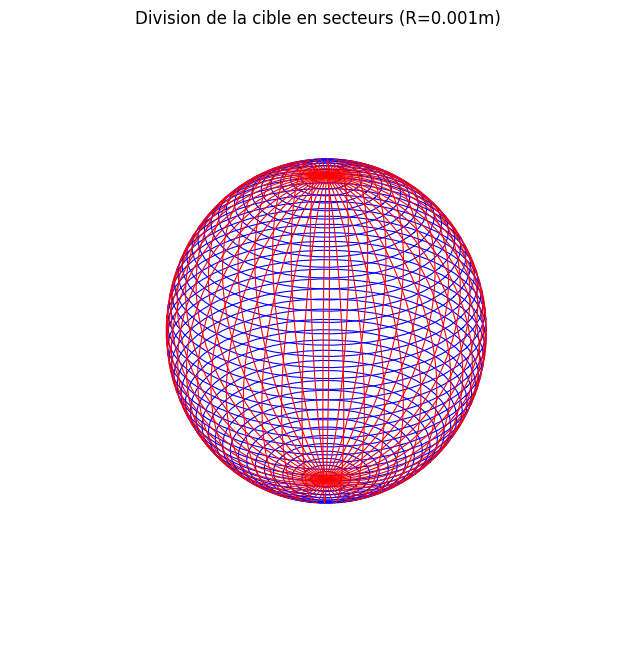

In [6]:
# 1. Création des secteurs (La grille est créée pour r=1 par défaut)
num_theta = 50
num_phi = 50
# On ne met PAS de radius ici, d'où l'erreur
sectors = rwhist.SphereSectors.factory(num_theta, num_phi) 

# 2. Affichage de la grille sur ta cible (Le radius se met ICI)
# La méthode plot_mesh remplace toutes tes boucles 'for' manuelles
fig, ax = sectors.plot_mesh(radius=TARGET_RADIUS)

# 3. Optionnel : On peut aussi afficher les centres des secteurs
# fig, ax = sectors.plot_centers(radius=TARGET_RADIUS, kwargs={'color': 'red', 's': 5})

ax.set_title(f"Division de la cible en secteurs (R={TARGET_RADIUS}m)")
plt.show()

Plot the center of each sectors on the mesh

Somme des aires calculées : 12.56637 (Attendu: 12.56637)


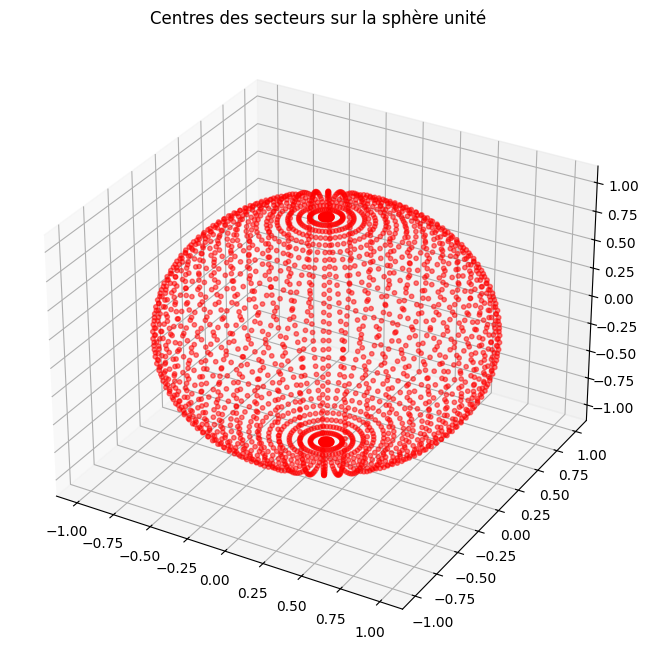

In [7]:
# 1. Calcul des aires et Vérification
# C'EST DÉJÀ FAIT ! factory() a déjà calculé 'sectors.areas' et vérifié la somme.
# Tu peux simplement vérifier la valeur si tu veux :
print(f"Somme des aires calculées : {np.sum(sectors.areas):.5f} (Attendu: {4*np.pi:.5f})")

# 2. Remplacement du scatter plot manuel
# La méthode plot_centers() fait déjà le 'coord.sph_to_cart' en interne.
# Tu peux passer tes paramètres graphiques (alpha, s, color) dans le dictionnaire 'kwargs'.
fig, ax = sectors.plot_centers(radius=1.0, kwargs={'alpha': 0.5, 's': 10, 'color': 'red'})

ax.set_title("Centres des secteurs sur la sphère unité")
plt.show()

## Histogram

In [8]:
hits = total_impact[total_impact['cs'] < 0]

df_hist = rwhist.compute_histogram(hits, sectors)

Import the 2D histogram into a csv file

In [9]:
from helpers import rwhist

# On reprend la colonne 'intensity' et on lui redonne sa forme 50x50
# .values transforme en NumPy, .reshape redonne la forme de la grille
histogram_numpy = df_hist['intensity'].values.reshape(sectors.mtheta.shape)


# 'hs_density' est la matrice 2D (50x50) calculée dans compute_histogram
# 'sectors' contient les bords (edges) de ta grille
rwhist.write_histogram(
    sectors.theta_edges, 
    sectors.phi_edges, 
    histogram_numpy, 
    "omega60_illumination_map.csv"
)

print("Fichier exporté pour le calcul des harmoniques sphériques.")

Fichier exporté pour le calcul des harmoniques sphériques.


## Showing 3D histogram

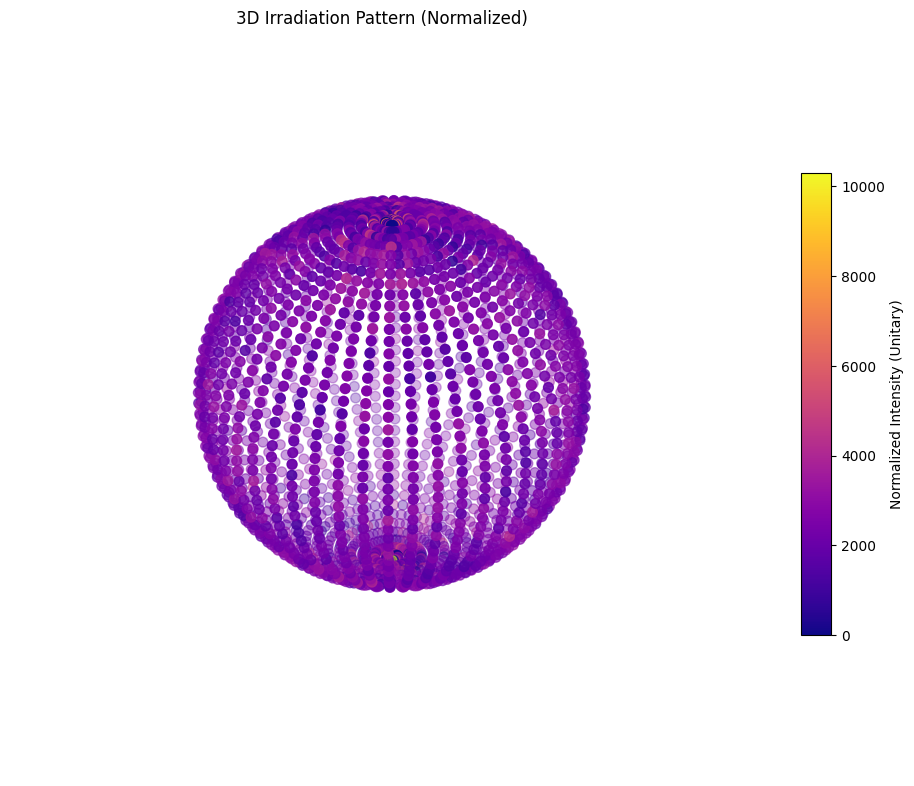

In [10]:
fig = plt.figure(figsize=(12, 12)) # Un peu plus petit pour que ce soit plus fluide
ax = fig.add_subplot(111, projection='3d')

# On récupère les valeurs (hs_unit est la normalisation physique que ton maître veut)
hs = df_hist['intensity'].values

# Conversion en coordonnées Cartésiennes
xs, ys, zs = coord.sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

X, Y, Z = xs.ravel(), ys.ravel(), zs.ravel()
C = hs.ravel() 

# --- LA CORRECTION EST ICI ---
# On force l'échelle de couleurs à coller au minimum et au maximum de tes données
# C'est ce qui transforme le "tout bleu" en "taches colorées"
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=50, vmin=C.min(), vmax=C.max())

# Colorbar (on l'affine un peu)
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=15)
cb.set_label("Normalized Intensity (Unitary)")

ax.set_box_aspect([1, 1, 1])
ax.set_title("3D Irradiation Pattern (Normalized)")
ax.set_axis_off()

plt.show()

## Integrated intensity

In [11]:
def compute_theta_distribution(df_final_map):
    """
    Intègre I(theta, phi) sur phi pour obtenir le profil moyen I(theta).
    Calcule également l'erreur relative globale du tir.
    """
    # 1. On regroupe par theta et on calcule la moyenne de l'intensité
    theta_profile = df_final_map.groupby('theta')['intensity'].mean().reset_index()
    
    # 2. Renommer pour la clarté
    theta_profile.columns = ['theta_rad', 'intensity_avg']
    
    # 3. Conversion en degrés pour le graphique
    theta_profile['theta_deg'] = np.degrees(theta_profile['theta_rad'])
    
    # 4. Normalisation du profil
    avg_total = theta_profile['intensity_avg'].mean()
    theta_profile['variation_pct'] = (theta_profile['intensity_avg'] / avg_total - 1) * 100
    
    # --- LIGNE AJOUTÉE ---
    # Calcul de l'erreur relative globale (e = std/mean) selon le schéma
    relative_error = df_final_map['intensity'].std() / df_final_map['intensity'].mean()
    
    return theta_profile, relative_error

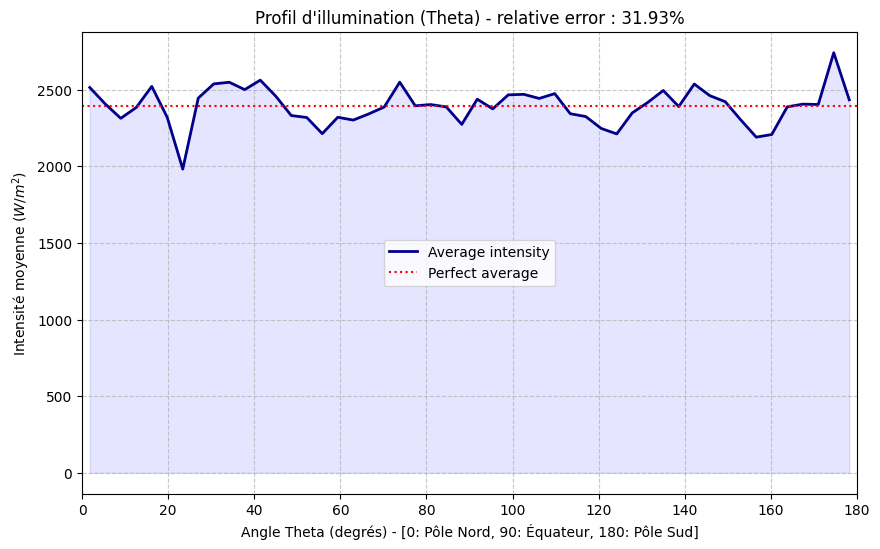

relative error is (std/mean) est de : 31.9294 %


In [12]:
# --- EXÉCUTION ---
# IMPORTANT : On récupère maintenant DEUX variables
df_theta, rel_err = compute_theta_distribution(df_hist)

# --- VISUALISATION ---
plt.figure(figsize=(10, 6))

# Tracé de la courbe
plt.plot(df_theta['theta_deg'], df_theta['intensity_avg'], color='darkblue', lw=2, label='Average intensity')
plt.fill_between(df_theta['theta_deg'], df_theta['intensity_avg'], color='blue', alpha=0.1)

# --- CHANGEMENT ICI : Affichage de l'erreur relative sur le graphique ---
# On affiche la valeur 'rel_err' (multipliée par 100 pour l'avoir en %)
plt.title(f"Profil d'illumination (Theta) - relative error : {rel_err*100:.2f}%")

# Esthétique
plt.xlabel("Angle Theta (degrés) - [0: Pôle Nord, 90: Équateur, 180: Pôle Sud]")
plt.ylabel("Intensité moyenne ($W/m^2$)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 180)

# Ajout d'une ligne horizontale pour l'intensité moyenne parfaite
plt.axhline(df_theta['intensity_avg'].mean(), color='red', linestyle=':', label='Perfect average')

plt.legend()
plt.show()

# Affichage dans le terminal pour ton suivi
print(f"relative error is (std/mean) est de : {rel_err*100:.4f} %")

Test cosign

In [13]:
def cosine_test(num_rays=1000000):
    
    # Generate parallel rays (force the direction)
    direction = np.array([-1, 0, 0]) 
    t1 = np.array([0, 1, 0])
    t2 = np.array([0, 0, -1])
    
    origins = sampler.sample_window(t1, t2, l1=0.003, l2=0.003, center=[1.65, 0, 0], num_points=num_rays)
    
    # Impact simulation
    hits_list = []
    for x0 in origins:
        res = sampler.ray_hit(x0, direction, radius=0.001, center=[0,0,0])
        if res[2] > 0:
            hits_list.append({
                'lat_rad': res[5][1], 
                'long_rad': res[5][2],
                'energy_weight': 1.0, # Uniform energy
                'cs': res[4]          # THE COSINE OF INCIDENCE
            })
    
    df_hits = pd.DataFrame(hits_list)
    
    # Process through the rwhist.compute_histogram function
    sectors = rwhist.SphereSectors.factory(num_theta=60, num_phi=120)
    df_res = rwhist.compute_histogram(df_hits, sectors)
    
    return df_res

2D intensity

In [14]:
# Application of the test in the case of a straight beam
sectors = rwhist.SphereSectors.factory(num_theta=60, num_phi=120)
df_res = cosine_test() 

theta_profile, error_globale = compute_theta_distribution(df_res) 

# C. On prépare la normalisation pour le graphique
max_val = theta_profile['intensity_avg'].max()

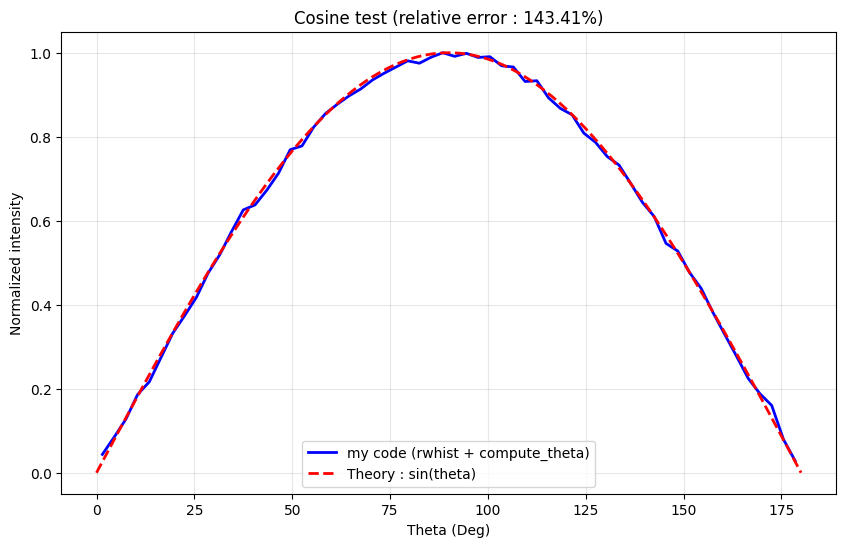

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# my simulation (blue)
plt.plot(theta_profile['theta_deg'], 
         theta_profile['intensity_avg'] / max_val, 
         label='my code (rwhist + compute_theta)', color='blue', lw=2)

# ideal function (red)
theta_theory = np.linspace(0, np.pi, 100)
plt.plot(np.degrees(theta_theory), np.sin(theta_theory), 
         'r--', label='Theory : sin(theta)', lw=2)

plt.title(f"Cosine test (relative error : {error_globale:.2%})")
plt.xlabel("Theta (Deg)")
plt.ylabel("Normalized intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Optimisation with sigma/mu

definition of the bounds

In [25]:
# Min values
FL_min = CHAMBER_RADIUS-TARGET_RADIUS
r_beam_min=0
defocus_min=-TARGET_RADIUS
sigma_gauss=0.0005

from scipy.integrate import quad
from scipy.optimize import root_scalar

# 1. Definition of the intensity profile I(r)
# Your Monte Carlo simulation uses a normal distribution (Gaussian)
# with a default standard deviation (scale) of 0.15 on the laser port.
# Here we define a generic Gaussian intensity function.
def intensity_profile(r, sigma):
    """Gaussian laser intensity profile."""
    return np.exp(-(r**2) / (2 * sigma**2))

# 2. Function F(R) calculating the cumulative energy up to radius R
def F(R, sigma):
    """Total energy contained within a disk of radius R."""
    # The integral is 2 * pi * integral(I(r) * r * dr) from 0 to R
    integrale, error = quad(lambda r: intensity_profile(r, sigma) * r, 0, R)
    return 2 * np.pi * integrale

def find_max_r_beam(sigma_gauss,eta_min=0.90, target_radius=0.001):
    """
    Finds the radius R_beam such that 90% of the total energy (F(R_beam))
    is contained within the target radius (F(target_radius)).
    """
    # K is the energy reaching the physical target (constant)
    K = F(target_radius, sigma_gauss)
    
    # Definition of G(R) = F(R) * eta - K
    # We search for the root of G(R), i.e., R such that F(R) = K / eta
    def G(R):
        return F(R, sigma_gauss) * eta_min - K

    # Root finding
    # The interval [target_radius, 0.5] widely covers the possibilities
    sol = root_scalar(G, bracket=[target_radius, 0.5], method='brentq')
    
    if sol.converged:
        return sol.root
    else:
        raise ValueError("R_beam search did not converge.")

ETA_MIN = 0.90         # 90% minimum energy on the target

# Max values
r_beam_max = find_max_r_beam(sigma_gauss,ETA_MIN, TARGET_RADIUS)*1000
FL_max = (WINDOW_SIZE * CHAMBER_RADIUS) / (WINDOW_SIZE - r_beam_max/1000)
defocus_max = (r_beam_max - TARGET_RADIUS*1000)
    
    
print(f"Maximum beam radius for {ETA_MIN*100}% energy: {r_beam_max:.4f} mm")
print(f"Maximum defocus for {ETA_MIN*100}% energy: {defocus_max} mm")   


Maximum beam radius for 90.0% energy: 1.2723 mm
Maximum defocus for 90.0% energy: 0.27230357491071455 mm


Class creation

In [26]:
class LaserOptimizer:
    def __init__(self, num_rays_per_beam=1000, target_radius=0.001):
        # Initialization of fixed parameters
        self.target_radius = target_radius
        self.num_rays_per_beam = num_rays_per_beam
        # Loading the initial configuration of the 60 OMEGA beams
        self.beams_df = geometry.get_omega60_dataframe()
        # Definition of sectors for statistical analysis
        self.sectors = rwhist.SphereSectors.factory(num_theta=50, num_phi=50)

    def __call__(self, defocus_mm):
        """
        Calculates g(FL) = sigma / mu for a given defocus
        """
        # 1. Update focus for all beams according to the new FL
        current_beams = self.beams_df.copy()
        # Apply the geometry function to recalculate fx, fy, fz
        f_coords = current_beams.apply(
            lambda row: geometry.assign_beam_focus(row, defocus_value=defocus_mm), 
            axis=1
        )
        current_beams[['fx', 'fy', 'fz']] = f_coords

        # 2. Impact simulation (Collision)
        # Use the collision module to obtain impacts on the target[cite: 2]
        total_impacts = collision.impact_simulated(
            num_total_rays=self.num_rays_per_beam * 60,
            target_radius=self.target_radius,
            target_center=np.array([0, 0, 0]),
            beam_df=current_beams
        )

        # 3. Intensity analysis (Histogram)
        # Calculate energy distribution on the sphere
        df_hist = rwhist.compute_histogram(total_impacts, self.sectors)
        
        # 4. Calculation of performance parameter g(FL) = sigma / mu
        # Extract intensity from each sector for statistics
        intensities = df_hist['intensity'].values
        mu = np.mean(intensities)
        sigma = np.std(intensities)
        
        # We aim to minimize this value for better uniformity
        return sigma / mu

Optimisation with minimize

In [27]:
from scipy.optimize import minimize_scalar
import numpy as np

# 1. Création de l'instance de votre classe
# On augmente le nombre de rayons pour plus de précision lors de l'optimisation
optimizer = LaserOptimizer(num_rays_per_beam=5000, target_radius=0.001)

# 2. Définition des bornes de recherche 
# La valeur de départ suggérée par Thales est implicitement couverte par ces bornes.
res = minimize_scalar(
    optimizer, 
    bounds=(defocus_min, defocus_max), 
    method='bounded', 
    options={'xatol': 0.1} # Précision de 0.1 mm
)

if res.success:
    print(f"Optimized defocus : {res.x:.2f} mm")
    print(f"minimal uniformitu sigma/mu : {res.fun:.4f}")
else:
    print("L'optimisation a échoué.")

Simulation terminée : 300000 impacts valides enregistrés.
Simulation terminée : 300000 impacts valides enregistrés.
Simulation terminée : 300000 impacts valides enregistrés.
Optimized defocus : 0.21 mm
minimal uniformitu sigma/mu : 0.8591


### 

## Pyvista representation 

In [19]:
import nest_asyncio

# On applique le patch une seule fois au début
nest_asyncio.apply()

def plot_omega_histogram_pyvista(sectors, hs, target_radius=0.001, cmap='plasma', filename="simulation_omega60.html"):
    """
    Affiche l'histogramme sphérique d'énergie sur la cible et exporte en HTML.
    """
    # 1. Conversion des coordonnées
    display_radius = target_radius * 1.05 
    xs, ys, zs = coord.sph_to_cart(display_radius, sectors.mtheta, sectors.mphi)

    # 2. Préparation des données
    points = np.column_stack([xs.ravel(), ys.ravel(), zs.ravel()])
    densities = hs.ravel()

    # 3. Création des objets PyVista
    point_cloud = pv.PolyData(points)
    point_cloud["Irradiance"] = densities
    target_sphere = pv.Sphere(radius=target_radius, center=(0, 0, 0), theta_resolution=100, phi_resolution=100)

    # 4. Configuration du Plotter
    pv.set_jupyter_backend('trame')
    plotter = pv.Plotter(window_size=[800, 600])
    plotter.background_color = "white"

    # Ajout des éléments à la scène
    plotter.add_mesh(target_sphere, color="lightgrey", opacity=0.3, label="Cible")
    plotter.add_mesh(
        point_cloud,
        scalars="Irradiance",
        cmap=cmap,
        render_points_as_spheres=True,
        point_size=10, 
        show_scalar_bar=True,
        scalar_bar_args={"title": "Energie normalisée (J/mm2)"}
    )

    plotter.add_title("Distribution Sphérique de l'Energie - OMEGA-60")
    plotter.add_legend()
    plotter.view_isometric()

    # --- ÉTAPE CRUCIALE : EXPORT AVANT LE SHOW ---
    # On utilise l'argument 'filename' passé à la fonction
    plotter.export_html(filename) 
    print(f"Fichier interactif sauvegardé : {filename}")

    # Affichage dans le Notebook
    plotter.show()

# --- UTILISATION ---
plot_omega_histogram_pyvista(sectors, hs, target_radius=TARGET_RADIUS, cmap='plasma', filename="simulation_omega60.html")

ValueError: Number of scalars (2500) must match either the number of points (7200) or the number of cells (7200).